> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

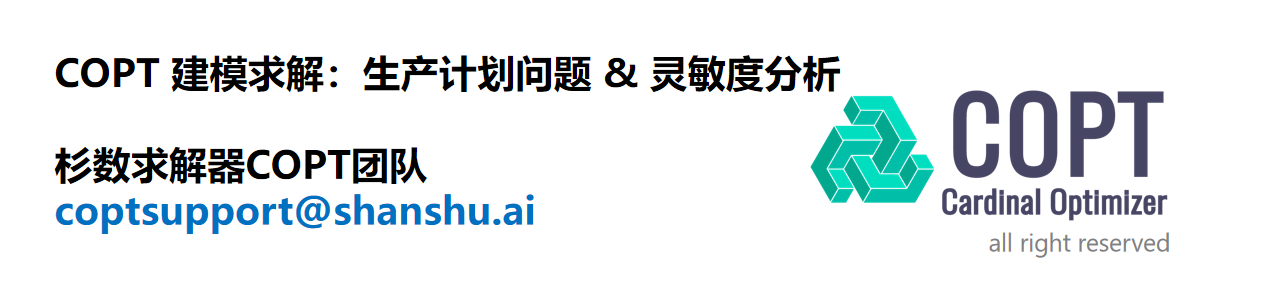

# 生产计划问题 & 灵敏度分析代码实现
## 使用 COPT 求解生产计划问题并进行灵敏度分析的步骤
1. **导入COPT-Python接口库** `coptpy`

2. **创建COPT求解环境与模型**

3. **构建模型：依次添加三要素**
    - **决策变量**：
        - 连续非负决策变量$X_i$，表示在计划年度内款式 $i$ 的生产数量（件）
    - **目标函数**：
        - 总利润最大化 
    - **约束条件**：
        - 装配工时上限约束
        - 抛光工时上限约束
        - 包装工时上限约束

4. **求解**

5. **灵敏度分析**：
    - 目标函数系数（利润）在什么区间变化时，当前最优基仍然保持不变；
    - 变量上下界在什么区间变化时，当前最优基不变；
    - 约束左右端（LHS/RHS）在什么区间内变化时，当前基仍然最优。


## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT
import numpy as np
import matplotlib.pyplot as plt

## 创建求解环境和求解模型

In [6]:
env = cp.Envr()
model = env.createModel("Production Planning Problem")
# 启用灵敏度分析
model.param.ReqSensitivity = 1

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved

Setting parameter 'ReqSensitivity' to 1


**<span style="color:rgb(0,0,255)">注意：灵敏度分析结果并非默认输出，需要在求解前设置参数</span>**

```python
# 启用灵敏度分析
model.param.ReqSensitivity = 1
```

设置该参数后，调用 `solve()` 时，线性规划经单纯形法求解完成后，求解器会自动计算各目标系数与约束右端项的允许变动范围，无需额外调用其他函数。随后即可通过相应信息读取灵敏度区间结果。需要注意的是，灵敏度分析需要基于最优基解（通过单纯形法求解或者crossover得到），因此该功能仅适用于线性规划（LP）问题。

## 添加模型三要素
### 添加决策变量
$X_i \in \mathbb{R}^+$：在计划年度内，款式 $i$ 的生产数量（件），为连续非负变量， $i \in \{1, 2, 3, 4\}$。
- `X1`：一年中生产款式 1 的数量  
- `X2`：一年中生产款式 2 的数量  
- `X3`：一年中生产款式 3 的数量  
- `X4`：一年中生产款式 4 的数量  

In [9]:
X1 = model.addVar(lb=0.0, name="X1")
X2 = model.addVar(lb=0.0, name="X2")
X3 = model.addVar(lb=0.0, name="X3")
X4 = model.addVar(lb=0.0, name="x4")

### 设置目标函数
最大化年度总利润：
$$ \max 1.5 X_1 + 2.5 X_2 + 3.0 X_3 + 4.5 X_4 $$

In [11]:
model.setObjective(1.5 * X1 + 2.5 * X2 + 3.0 * X3 + 4.5 * X4, COPT.MAXIMIZE)

### 添加约束条件
1. **装配工时上限约束**：所有款式消耗的装配总工时不得超过系统装配产能上限。
$$ 2X_1 + 4X_2 + 3X_3 + 7X_4 \le 100000 $$

In [13]:
model.addConstr(2 * X1 + 4 * X2 + 3 * X3 + 7 * X4 <= 100000, name="AssemblyTime")

<coptpy.Constraint: AssemblyTime>

2. **抛光工时上限约束**：所有款式消耗的抛光总工时不得超过系统抛光产能上限。
$$ 3X_1 + 2X_2 + 3X_3 + 4X_4 \le 50000 $$

In [15]:
model.addConstr(3 * X1 + 2 * X2 + 3 * X3 + 4 * X4 <= 50000, name="PolishTime")

<coptpy.Constraint: PolishTime>

3. **包装工时上限约束**：所有款式消耗的包装总工时不得超过系统包装产能上限。
$$ 2X_1 + 3X_2 + 2X_3 + 5X_4 \le 60000 $$

In [17]:
model.addConstr(2 * X1 + 3 * X2 + 2 * X3 + 5 * X4 <= 60000, name="PackTime")

<coptpy.Constraint: PackTime>

## 求解

In [19]:
model.solve()

Model fingerprint: eafe3cc4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    3 rows, 4 columns and 12 non-zero elements
The presolved problem has:
    3 rows, 4 columns and 12 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [5e-01,2e+00]
    Range of rhs coefficients:       [5e+04,1e+05]
    Range of bound coefficients:     [0e+00,0e+00]
    Range of cost coefficients:      [6e-01,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    1.7900248463e+05            3           0       0.05s
Dual             4    5.8000255410e+04            0           0       0.05s
Postsolving
Dual             4    5.8000000000e+04            0           0       

## 获取结果
### 打印模型的最优解

In [21]:
def print_result(model):
    print("\n===== Optimal Solution =====")

    # 1. 打印目标值
    print(f"Objective value: {model.objval}")

    # 2. 打印变量值
    print("\nDecision Variables:")
    allvars = model.getVars()
    for var in allvars:
        print("{0} 最优值：{1:.4f}, 基状态：{2}, Reduced cost：{3:.4f}".format(var.name, var.x, int(var.basis), var.rc))

    # 3. 打印约束松弛量与对偶值
    print("\nConstraints:")
    for c in model.getConstrs():
        row = model.getRow(c)
        slack = c.Slack
        dual = c.Pi  # 对偶值（影子价格）
        print(f"  {c.name}: Slack = {slack}, Dual = {dual}")


In [22]:
if model.status == COPT.OPTIMAL:
    print_result(model)
else:
    print("No optimal solution.")


===== Optimal Solution =====
Objective value: 58000.0

Decision Variables:
X1 最优值：0.0000, 基状态：0, Reduced cost：-1.5000
X2 最优值：16000.0000, 基状态：1, Reduced cost：-0.0000
X3 最优值：6000.0000, 基状态：1, Reduced cost：-0.0000
x4 最优值：0.0000, 基状态：0, Reduced cost：-0.2000

Constraints:
  AssemblyTime: Slack = 82000.0, Dual = 0.0
  PolishTime: Slack = 50000.0, Dual = 0.8
  PackTime: Slack = 60000.0, Dual = 0.2999999999999998


- **决策变量基状态的含义**：决策变量X2和X3的基状态值为1，根据线性规划课程中的单纯形法理论，在非退化的情形下，这表明 X2 和 X3 是构成当前最优解的**基变量（Basic Variables）**。
- **reduced cost的含义**：根据单纯形法理论，决策变量的 reduced cost 对应其在单纯形表中的检验数（$\sigma_j$）。在达到最优解的状态下，已经被选入生产计划的基变量，其检验数恒为 0；而未被投入生产的非基变量的检验数不为 0。

**经济学意义**：

**reduced cost** 直观地反映了在当前最优决策下，对决策变量进行微小扰动（例如强行安排生产）对目标函数值带来的边际影响。对于最大化利润问题，如果某个决策变量的 reduced cost $<0$，则明确表示该款式当前不值得生产。换言之，若强行生产 1 件该款式，不仅不能增加收益，反而会挤占其他更有价值的资源，导致总利润下降相应的金额。只有当该款式的单位利润至少提升这个差额时，它才具备重新投产的经济价值。

### 打印灵敏度分析结果
在 COPT 求解器中，灵敏度分析结果是通过获取变量和约束的特定信息（COPT.Info类）来实现的。以下是 COPT 求解和灵敏度分析结果常用信息：

| 信息名称 | 含义说明 |
| :--- |  :--- |
| `SAObjLow` | 目标函数系数的灵敏度分析下界|
| `SAObjUp` | 目标函数系数的灵敏度分析上界 |
| `SALBLow` | 变量或约束下界的灵敏度分析下界 |
| `SALBUp` | 变量或约束下界的灵敏度分析上界 |
| `SAUBLow` | 变量或约束上界的灵敏度分析下界 |
| `SAUBUp` | 变量或约束上界的灵敏度分析上界 |

1. 对于**目标函数系数**，例如本案例中各款产品的单位利润，其允许的变化区间代表了在当前最优生产策略不变的前提下，利润所能波动的安全范围，该区间可以通过 `COPT.Info.SAObjLow` 和 `COPT.Info.SAObjUp` 获取。

2. 对于**模型约束条件**，COPT 在底层统一采用双边约束的形式来表达，即 $L \le Ax \le U$。
  - 如果是 $\le$ 约束，例如本案例中的产能上限约束，核心在于关注**上界**（UB，即输出中的 RHS），其允许变化区间通过 `COPT.Info.SAUBLow` 和 `COPT.Info.SAUBUp` 获取。
  - 如果是 $\ge$ 约束，核心在于关注**下界**（LB，即输出中的 LHS），其允许变化区间通过 `COPT.Info.SALBLow` 和 `COPT.Info.SALBUp` 获取。


In [25]:
def print_sensitivity(model):
    vars = model.getVars()
    cons = model.getConstrs()

    obj_low = model.getInfo(COPT.Info.SAObjLow, vars)
    obj_upp = model.getInfo(COPT.Info.SAObjUp, vars)
    print("")
    print("Variant\tObjective Range")
    for i in range(vars.size):
        print(f"  {vars[i].name}\t({obj_low[i]}, {obj_upp[i]})")

    lb_low = model.getInfo(COPT.Info.SALBLow, vars)
    lb_upp = model.getInfo(COPT.Info.SALBUp, vars)
    ub_low = model.getInfo(COPT.Info.SAUBLow, vars)
    ub_upp = model.getInfo(COPT.Info.SAUBUp, vars)
    print("")
    print("Variant\tLowBound Range  \tUppBound Range")
    for i in range(vars.size):
        print(f"  {vars[i].name}\t({lb_low[i]}, {lb_upp[i]})\t({ub_low[i]}, {ub_upp[i]})")

    rowlb_low = model.getInfo(COPT.Info.SALBLow, cons)
    rowlb_upp = model.getInfo(COPT.Info.SALBUp, cons)
    rowub_low = model.getInfo(COPT.Info.SAUBLow, cons)
    rowub_upp = model.getInfo(COPT.Info.SAUBUp, cons)
    print("")
    print("Constraint\tLHS Range         \tRHS Range")
    for i in range(cons.size):
        print(f"  {cons[i].name}\t({rowlb_low[i]}, {rowlb_upp[i]})\t({rowub_low[i]}, {rowub_upp[i]})")

In [26]:
# Show the results of sensitivity analysis
if model.status == COPT.OPTIMAL:
    if model.HasSensitivity:
        print("")
        print("Sensitivity information of production planning problem:")
        print_sensitivity(model)
    else:
        print("Sensitivity information is not available")
else:
    print("Optimal solution is not available, with status " + str(model.status))


Sensitivity information of production planning problem:

Variant	Objective Range
  X1	(-1e+30, 3.0)
  X2	(2.3571428571428577, 4.5)
  X3	(2.5000000000000018, 3.7499999999999996)
  x4	(-1e+30, 4.699999999999999)

Variant	LowBound Range  	UppBound Range
  X1	(-18000.0, 6000.0)	(0.0, 1e+30)
  X2	(-1e+30, 16000.0)	(16000.0, 1e+30)
  X3	(-1e+30, 6000.0)	(6000.0, 1e+30)
  x4	(-1e+30, 11428.571428571431)	(0.0, 1e+30)

Constraint	LHS Range         	RHS Range
  AssemblyTime	(-1e+30, 82000.0)	(82000.0, 1e+30)
  PolishTime	(-1e+30, 50000.0)	(40000.0, 90000.0)
  PackTime	(-1e+30, 60000.0)	(33333.33333333333, 75000.0)


通过灵敏度分析结果，可以知道在保持当前最优生产策略不变的前提下，各项核心参数的允许变化区间如下：

1. **目标函数系数的允许波动区间**：

各款式产品的单位利润存在一个明确的安全波动区间。以产品款式 2 为例，其当前利润为 2.50 元，灵敏度分析显示其变化区间为 2.36 至 4.50 元。这意味着只要市场价格波动没有跌破 2.36 元或暴涨超过 4.50 元，目前的生产计划组合仍是最优的。对于未投产的款式 4，其当前利润 4.50 元距离右侧上边界 4.70 元非常接近，一旦市场报价微涨 0.20 元，整体生产组合就需要重新调整。

2. **约束条件边界的允许波动区间**：

以装配工时为例，这是一个上限约束，原始系统设计容量为 100,000 分钟。输出结果显示其上限变化区间为 82000.00 至正无穷大。这是因为实际生产中仅消耗了 82,000 分钟，系统总装配产能只要不低于这个实际消耗量，对当前的最优生产计划就不会产生任何影响。相反，抛光工时的上限变化区间为 40000.00 至 90000.00 分钟，这为设备定期检修导致的产能缩减，或临时安排加班导致的产能扩张提供了可量化的安全决策边界。

### 目标函数系数的灵敏度分析可视化

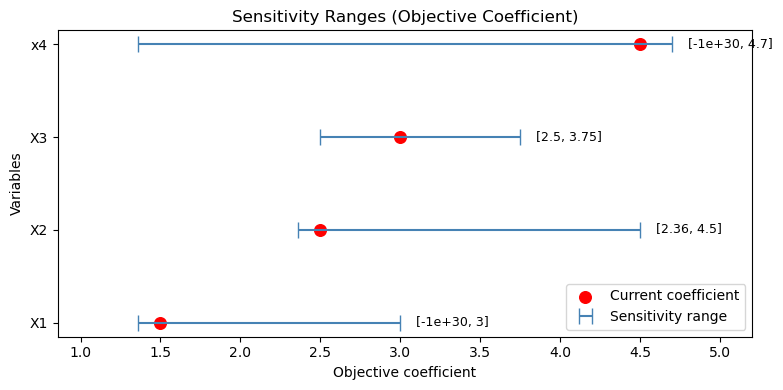

In [29]:
# 1. 读原始灵敏度结果
vars_ = model.getVars()
names = [v.name for v in vars_]

obj_low_raw = np.array(model.getInfo(COPT.Info.SAObjLow, vars_), dtype=float)
obj_upp_raw = np.array(model.getInfo(COPT.Info.SAObjUp, vars_), dtype=float)
cur_coef = np.array([v.Obj for v in vars_], dtype=float)

# 2. 找有限边界
finite_lows = obj_low_raw[obj_low_raw > -1e20]
finite_upps = obj_upp_raw[obj_upp_raw <  1e20]

min_finite = finite_lows.min()
max_finite = finite_upps.max()

# 3. 替换 -inf/+inf
NEG_INF = min_finite - 1.0
POS_INF = max_finite + 1.0

low_plot = np.where(obj_low_raw < -1e20, NEG_INF, obj_low_raw)
upp_plot = np.where(obj_upp_raw >  1e20, POS_INF, obj_upp_raw)

# 中点+误差
mid = (low_plot + upp_plot) / 2
err_low = mid - low_plot
err_upp = upp_plot - mid

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 4))

# 区间横线
ax.errorbar(
    x=mid,
    y=names,
    xerr=[err_low, err_upp],
    fmt="none",
    ecolor="steelblue",
    capsize=6,
    label="Sensitivity range",
)

# 当前目标系数
ax.scatter(
    cur_coef,
    names,
    marker="o",
    s=70,
    color="red",
    label="Current coefficient",
)

# 标注原始区间
for i, name in enumerate(names):
    ax.text(
        upp_plot[i] + 0.1,
        name,
        f"[{obj_low_raw[i]:.3g}, {obj_upp_raw[i]:.3g}]",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Objective coefficient")
ax.set_ylabel("Variables")
ax.set_title("Sensitivity Ranges (Objective Coefficient)")

# 自动 xlim
ax.set_xlim(min(low_plot) - 0.5, max(upp_plot) + 0.5)

ax.legend()
plt.tight_layout()
plt.show()


上图给出了四款产品利润系数的允许变动范围，即在当前最优生产方案保持不变的前提下，各产品单位利润可以上下浮动的区间：

- 对于未投产产品（款式1和款式4），其左侧一直延伸至负无穷大（`-1e+30`）， **关键转折点在于右侧边界**，款式 1 当前利润远低于安全区间上限，极度缺乏竞争力；而款式 4 当前利润距离触发投产的区间上限非常近，微小的市场溢价即可令其重启生产。
- 对于生产的产品（款式2和款式3），款式 2 当前利润接近安全下界，对降价促销或成本上涨较为敏感，预警了较高的停产风险；相比之下，款式 3 在区间内分布更为居中，这为企业的销售与定价部门提供了更多可操作空间，明确了可容忍的最大降价促销程度以及涨价的安全范围。

### 资源使用情况对比与影子价格可视化

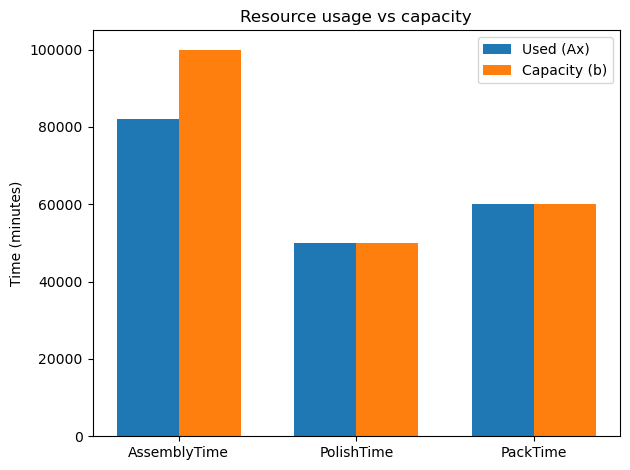

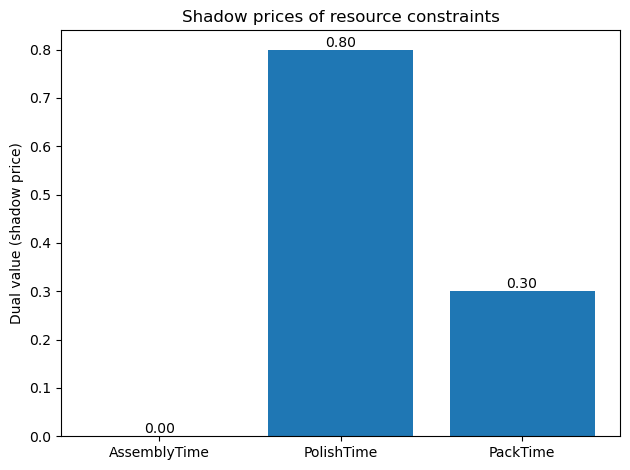

In [32]:
cons_ = model.getConstrs()

names = [c.name for c in cons_]
lhs_used = []   # Ax
rhs_cap = []    # RHS
duals = []      # Pi

for c in cons_:
    lhs_used.append(c.Slack)   # 在 COPT 中 Slack 实际是 Ax（左端值）
    rhs_cap.append(c.UB)       
    duals.append(c.Pi)

lhs_used = np.array(lhs_used, dtype=float)
rhs_cap = np.array(rhs_cap, dtype=float)
duals = np.array(duals, dtype=float)

# 图 1：资源使用情况
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, lhs_used, width, label="Used (Ax)")
ax.bar(x + width/2, rhs_cap, width, label="Capacity (b)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Time (minutes)")
ax.set_title("Resource usage vs capacity")
ax.legend()
plt.tight_layout()
plt.show()

# 图 2：影子价格
fig, ax = plt.subplots()
ax.bar(names, duals)
ax.set_ylabel("Dual value (shadow price)")
ax.set_title("Shadow prices of resource constraints")

for i, v in enumerate(duals):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


这两张图表揭示了生产流程中的系统短板以及打破短板所能带来的边际收益。

- 对于资源使用情况，装配工时（AssemblyTime）的实际消耗远低于约束上限，存在严重的产能闲置。核心瓶颈在于抛光与包装环节，这两个环节的工时利用率达 100%，说明它们是目前制约企业进一步扩大生产规模、提升利润的核心瓶颈。

- 对于产能扩充的投资回报，处于过剩状态的装配工时影子价格为 0，表示追加该项资源无利可图。相比之下，抛光工时的影子价格最高，包装工时次之，如果企业有额外的资金预算用于设备扩容，应优先向抛光车间倾斜资源，其次是包装车间，以获取最大边际利润。